# BERT LLM Hallucination Detector

### Imports

In [15]:
import numpy as np
import torch
from datasets import load_dataset, load_from_disk
from transformers import (
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
    Trainer,
    TrainingArguments,
)

# ---- configuration ---------------------------------------------------------
MODEL_NAME = "xlm-roberta-base"
MAX_LENGTH = 512
SEED = 42
NUM_EPOCHS = 5
OFFICIAL_CUTOFF = 0.5
RUN_NAME = f"{MODEL_NAME.split('/')[-1]}-silver"
OUTPUT_DIR = f"./{RUN_NAME}-checkpoints"
FINAL_MODEL_DIR = f"./{RUN_NAME}-final"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("torch", torch.__version__, "| cuda", torch.version.cuda, "| device:", DEVICE)
if DEVICE == "cuda":
    print(torch.cuda.get_device_name(0))
print(f"run: {RUN_NAME} -> {FINAL_MODEL_DIR}")

torch 2.11.0+cu128 | cuda 12.8 | device: cuda
NVIDIA GeForce RTX 5070 Laptop GPU
run: xlm-roberta-base-silver -> ./xlm-roberta-base-silver-final


### Step 2: Data Loading

In [16]:
dataset = load_dataset("Helsinki-NLP/mu-shroom", "all")

# Access splits
val = dataset["validation"]
test = dataset["test"]
train = load_from_disk(
    "temp_mu_shroom_llm_annotated_train_new"
)

# Finally bert model training and evaluation



12. Train BERT/XLM-R token classification model on the annotated dataset using hard/soft labels

1. Tokenize the dataset using the BERT tokenizer

In [17]:
# MODEL_NAME and DEVICE come from the configuration block at the top of the
# notebook; swapping the encoder is a one-line change there, not here.
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

print(f"{MODEL_NAME} on {DEVICE}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] XLMRobertaForTokenClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


xlm-roberta-base on cuda


2. Offset mapping

In [18]:
def spans_to_character_array(text, spans):
    """
    Expand official `[start, end)` spans into a per-character 0/1 array.

    The saved silver dataset stores `hard_labels` in the **official** Mu-SHROOM
    format - a list of half-open character spans - which is the same format the
    gold `validation` / `test` splits use. Token alignment needs the opposite
    representation (one label per character), so this undoes the run-length
    encoding.

    Args:
        text (str): the answer the spans index into.
        spans (Sequence[Sequence[int]]): `[[start, end], ...]`, end-exclusive.

    Returns:
        numpy.ndarray: `int8` array of length `len(text)`, 1 where hallucinated.

    Example:
        >>> spans_to_character_array("abcdef", [[1, 3]]).tolist()
        [0, 1, 1, 0, 0, 0]
    """
    labels = np.zeros(len(text), dtype=np.int8)

    for start, end in spans:
        labels[int(start):int(end)] = 1

    return labels


In [19]:
def encode_pair(question, answer, max_length=MAX_LENGTH):
    """
    Tokenize a (question, answer) pair, protecting the answer from truncation.

    The question goes first: ATLANTIS (arXiv:2508.05179) ablated placement and
    found the question at the beginning works best.

    `truncation="only_first"` trims the question and never the answer. That
    matters because every gold character offset indexes the answer - trimming
    the answer costs recall, trimming the question costs nothing.

    It has one failure mode. When the answer *alone* is longer than
    `max_length` there is nothing left to take off the question, and the fast
    tokenizer raises rather than returning an over-long sequence. Measured on
    this data that is 54 of 3,285 silver rows (1.6%), 5 of 499 validation rows
    (1.0%) and 14 of 1,902 test rows (0.7%). For those, `longest_first` falls
    back to trimming the answer - exactly the recall loss the answer-only setup
    already accepted. The `tokenizers` library raises a bare `Exception` here,
    which is why the catch is broad.

    Args:
        question (str): `model_input`.
        answer (str): `model_output_text`; the returned offsets index this.
        max_length (int): combined token budget for both sequences.

    Returns:
        transformers.BatchEncoding: carries `offset_mapping`, and
        `sequence_ids()` returns 1 on exactly the answer tokens.

    Example:
        >>> encoding = encode_pair("Who won?", "Alice won in 1999.")
        >>> encoding.sequence_ids().count(1) > 0
        True
    """
    try:
        return tokenizer(
            question,
            answer,
            truncation="only_first",
            max_length=max_length,
            return_offsets_mapping=True,
        )

    except Exception:
        return tokenizer(
            question,
            answer,
            truncation="longest_first",
            max_length=max_length,
            return_offsets_mapping=True,
        )


def tokenize_and_align_labels(example):
    """
    Tokenize one (question, answer) pair and project character labels onto tokens.

    Only the answer is labelled. Question tokens, the separators and the
    special tokens all get -100, so the loss sees exactly the span the official
    metric scores - the question is context the model may attend to, never
    something it is asked to classify.

    A token is labelled 1 if **any** of its characters is hallucinated. Rows
    come out unpadded; `DataCollatorForTokenClassification` pads each batch to
    its own longest row and pads `labels` with -100.

    Works unchanged on the silver train split and on gold validation/test: all
    three store `hard_labels` as official `[start, end]` character spans, and
    all three carry `model_input`.

    `offset_mapping` is popped because the Trainer would otherwise forward it
    to the model as an unexpected keyword argument.

    Args:
        example (dict): a row with `model_input`, `model_output_text` and
            `hard_labels` as official `[start, end]` spans.

    Returns:
        dict: `input_ids`, `attention_mask` and `labels`, one entry per token.

    Example:
        >>> encoded = tokenize_and_align_labels(val[0])
        >>> len(encoded["input_ids"]) == len(encoded["labels"])
        True
        >>> set(encoded["labels"]) <= {-100, 0, 1}
        True
    """
    text = example["model_output_text"]

    # hard_labels holds official spans, so expand them back to characters
    char_labels = spans_to_character_array(text, example["hard_labels"])

    encoding = encode_pair(example["model_input"], text)

    sequence_ids = encoding.sequence_ids()

    token_labels = []

    for index, (start, end) in enumerate(encoding["offset_mapping"]):

        # sequence 1 is the answer; everything else is context or special
        if sequence_ids[index] != 1 or start == end:
            token_labels.append(-100)
            continue

        # if any character in this token is hallucinated
        token_labels.append(
            1 if char_labels[start:end].any() else 0
        )

    encoding["labels"] = token_labels

    # remove offset mapping
    encoding.pop("offset_mapping")

    return encoding

In [20]:
train.column_names

['id',
 'lang',
 'model_input',
 'model_output_text',
 'model_id',
 'wikipedia_url',
 'soft_labels',
 'hard_labels',
 'model_output_logits',
 'model_output_tokens',
 'annotations',
 'n_valid_votes',
 'n_votes']

In [21]:
import datasets
datasets.disable_caching()
tokenized_train = train.map(
    tokenize_and_align_labels,
    remove_columns=train.column_names,
)

tokenized_val = val.map(
    tokenize_and_align_labels,
    remove_columns=val.column_names,
)

print(f"tokenized train: {len(tokenized_train)} rows")
print(f"tokenized val:   {len(tokenized_val)} rows")

# sanity check: labels line up with tokens and only ever take the 3 legal values
example = tokenized_train[0]
assert len(example["input_ids"]) == len(example["labels"])
assert set(example["labels"]) <= {-100, 0, 1}
print(f"first row: {len(example['input_ids'])} tokens, "
      f"{sum(1 for l in example['labels'] if l == 1)} labelled hallucinated")


Map:   0%|          | 0/3327 [00:00<?, ? examples/s]

Map:   0%|          | 0/499 [00:00<?, ? examples/s]

tokenized train: 3327 rows
tokenized val:   499 rows
first row: 45 tokens, 29 labelled hallucinated


In [22]:
print(train[1])
tokenized_train[1]['labels']

{'id': 1, 'lang': 'EN', 'model_input': 'Do all arthropods have antennae?', 'model_output_text': ' Yes, all insects and arachnids have at least one antenna. ', 'model_id': 'togethercomputer/Pythia-Chat-Base-7B', 'wikipedia_url': None, 'soft_labels': [{'start': 1, 'prob': 0.4444444444444444, 'end': 6}, {'start': 6, 'prob': 1.0, 'end': 57}, {'start': 57, 'prob': 0.2222222222222222, 'end': 58}], 'hard_labels': [[6, 57]], 'model_output_logits': [-2.57427001, 5.1865358353, 5.4173498154, 2.3298389912, 6.6413722038, 3.5858919621, 10.0333786011, 4.0347309113, 2.5324678421, 0.595354557, 3.7296099663, 14.31341362, -1.5164659023, 3.9656012058, 4.8837690353, 3.5321044922, 15.5193033218], 'model_output_tokens': ['ĠYes', ',', 'Ġall', 'Ġinsects', 'Ġand', 'Ġar', 'ach', 'n', 'ids', 'Ġhave', 'Ġat', 'Ġleast', 'Ġone', 'Ġantenna', '.', 'Ċ'], 'annotations': [{'annotator_id': '', 'labels': []}], 'n_valid_votes': 18, 'n_votes': 18}


[-100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 -100,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 -100]

4. Splits

The dataset already ships the split we need, so **no `train_test_split`**:

| role | source | labels |
|---|---|---|
| train | silver-annotated `train_unlabeled` | LLM ensemble (ours) |
| validation | gold `validation` | **human** |
| test | gold `test` | **human**, held out until the very end |

Holding a slice out of the silver data would only have measured agreement with
our own LLM annotators. Evaluating on the gold `validation` split instead means
early stopping and checkpoint selection are driven by **human** labels, and the
gold `test` split stays untouched until the final evaluation section.


In [23]:
# No train_test_split: the shared task already defines the splits.
#
# train_dataset -> our silver labels  (3,285 rows, EN/ES/FR/ZH)
# eval_dataset  -> gold validation    (499 rows, 10 languages, human labels)
#
# Because eval_dataset is gold, every metric the Trainer prints per epoch is a
# score against humans, not against our own annotator ensemble.
train_dataset = tokenized_train
eval_dataset = tokenized_val

print(f"train: {len(train_dataset)} rows (silver)")
print(f"eval:  {len(eval_dataset)} rows (gold validation)")


train: 3327 rows (silver)
eval:  499 rows (gold validation)


5. train setup

In [24]:
from sklearn.metrics import precision_recall_fscore_support


def compute_metrics(eval_pred):
    """
    Positive-class precision / recall / F1 for token classification.

    """
    logits, labels = eval_pred

    # transformers may hand back a tuple when the model returns extra outputs
    if isinstance(logits, tuple):
        logits = logits[0]

    predictions = np.argmax(logits, axis=-1)

    mask = labels != -100
    y_true = labels[mask]
    y_pred = predictions[mask]

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        pos_label=1,
        zero_division=0,
    )

    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "predicted_positive_rate": float(y_pred.mean()),
    }


# lr 2e-5 is the shared task's own XLM-R baseline recipe (arXiv:2504.11975,
# footnote 7), which keeps the run comparable to it. The epoch count is ours:
# see NUM_EPOCHS at the top for why it is 2 rather than the baseline's 5.
#
# Every path, seed and length comes from the configuration block, so a rerun
# with a different encoder lands in its own directory and stays reproducible.
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=NUM_EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    load_best_model_at_end=True,
    # eval_loss would rank a do-nothing model highly at this class balance,
    # so select the checkpoint on positive-class F1 against gold instead.
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=SEED,
    # fp16 on CPU raises rather than falling back, so gate it on the device
    fp16=(DEVICE == "cuda"),
)


6. train model

In [25]:
# Dynamic padding: tokenize_and_align_labels emits unpadded rows, so the
# collator pads each batch to its own longest row and fills `labels` with -100.
# The default collator cannot do that and would fail on ragged rows.
data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=tokenizer,   # transformers v5 name for the old `tokenizer=`
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

trainer.save_model(FINAL_MODEL_DIR)
tokenizer.save_pretrained(FINAL_MODEL_DIR)

print(f"best checkpoint saved to {FINAL_MODEL_DIR}")


Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Predicted Positive Rate
1,0.504280,0.697650,0.592709,0.330743,0.424568,0.228119
2,0.448393,0.767085,0.577836,0.415386,0.483326,0.293874
3,0.338579,0.939297,0.537712,0.509078,0.523003,0.387033
4,0.270572,0.966378,0.561717,0.460077,0.505842,0.334831
5,0.221276,1.074098,0.562230,0.450118,0.499966,0.327285


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

best checkpoint saved to ./xlm-roberta-base-silver-final


#### Training and evaluation loss curves

saved xlm-roberta-base-silver_loss_curves.png


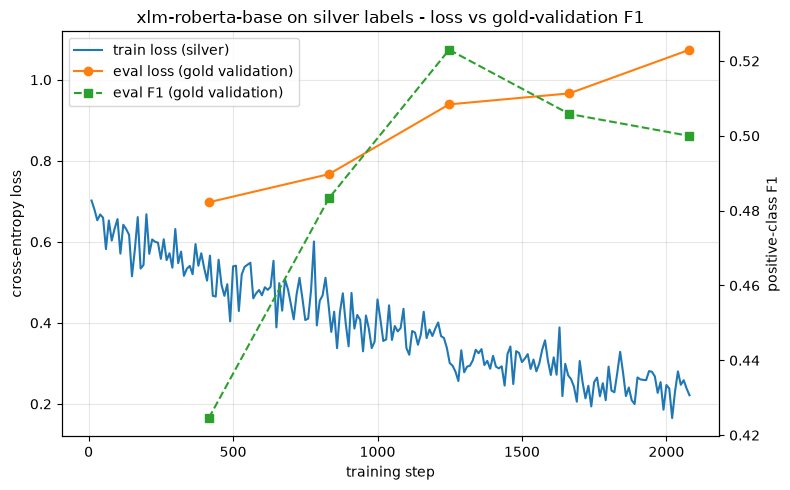

epoch  1.0 | step   416 | eval_loss 0.6977 | eval_f1 0.4246
epoch  2.0 | step   832 | eval_loss 0.7671 | eval_f1 0.4833
epoch  3.0 | step  1248 | eval_loss 0.9393 | eval_f1 0.5230
epoch  4.0 | step  1664 | eval_loss 0.9664 | eval_f1 0.5058
epoch  5.0 | step  2080 | eval_loss 1.0741 | eval_f1 0.5000


In [26]:
def get_loss_history(trainer):
    """
    Pull the training and evaluation curves out of a finished Trainer.

    `trainer.state.log_history` interleaves two kinds of entry: optimizer logs
    carrying `loss` (every `logging_steps`) and evaluation logs carrying
    `eval_loss` and the `compute_metrics` output (every epoch). This splits them
    into aligned series on a shared step axis so they can be plotted or printed
    without matplotlib.

    Args:
        trainer (transformers.Trainer): a Trainer whose `train()` has run.

    Returns:
        dict: `{"train": [(step, loss), ...], "eval": [(step, loss), ...],
        "eval_f1": [(step, f1), ...], "eval_epochs": [epoch, ...]}`.

    Example:
        >>> history = get_loss_history(trainer)
        >>> len(history["eval"])
        2
    """
    log_history = trainer.state.log_history

    return {
        "train": [
            (entry["step"], entry["loss"])
            for entry in log_history
            if "loss" in entry and "eval_loss" not in entry
        ],
        "eval": [
            (entry["step"], entry["eval_loss"])
            for entry in log_history
            if "eval_loss" in entry
        ],
        "eval_f1": [
            (entry["step"], entry["eval_f1"])
            for entry in log_history
            if "eval_f1" in entry
        ],
        "eval_epochs": [
            entry.get("epoch")
            for entry in log_history
            if "eval_loss" in entry
        ],
    }


def plot_loss_curves(trainer, save_path="loss_curves.png"):
    """
    Plot training loss against gold-validation loss, with F1 on a second axis.

    Two things are worth reading off this plot, and they disagree with each
    other on this task. The loss gap is the usual overfitting signal - train
    falling while eval flattens or rises. The F1 curve is what checkpoint
    selection actually uses, and in the completed run it kept improving while
    eval_loss rose: cross-entropy punishes confident errors, F1 scores
    decisions, and the two rank epochs differently. Selecting on loss would
    pick epoch 1; selecting on F1 picks epoch 2, which is the better model.

    Falls back to printing the same numbers when matplotlib is unavailable, so
    the cell never breaks the run.

    Args:
        trainer (transformers.Trainer): a Trainer whose `train()` has run.
        save_path (str | None): PNG destination, or None to skip saving.

    Returns:
        dict: the history from `get_loss_history`.

    Example:
        >>> history = plot_loss_curves(trainer)
        saved loss_curves.png
        >>> len(history["train"]) > 0
        True
    """
    history = get_loss_history(trainer)

    if not history["train"] and not history["eval"]:
        print("No loss logged - has trainer.train() been run in this session?")
        return history

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        plt = None

    if plt is None:
        print("matplotlib is not installed - run `pip install matplotlib` for the plot.")
        print(f"{'step':>8} {'train_loss':>12} {'eval_loss':>12} {'eval_f1':>10}")

        eval_f1 = dict(history["eval_f1"])

        for step, loss in history["train"]:
            print(f"{step:>8} {loss:>12.4f} {'':>12} {'':>10}")

        for step, loss in history["eval"]:
            print(f"{step:>8} {'':>12} {loss:>12.4f} "
                  f"{eval_f1.get(step, float('nan')):>10.4f}")

        return history

    figure, axis = plt.subplots(figsize=(8, 5))

    if history["train"]:
        axis.plot(
            [step for step, _ in history["train"]],
            [loss for _, loss in history["train"]],
            label="train loss (silver)",
            linewidth=1.5,
        )

    if history["eval"]:
        axis.plot(
            [step for step, _ in history["eval"]],
            [loss for _, loss in history["eval"]],
            label="eval loss (gold validation)",
            linewidth=1.5,
            marker="o",
        )

    axis.set_xlabel("training step")
    axis.set_ylabel("cross-entropy loss")
    axis.set_title(f"{MODEL_NAME} on silver labels - loss vs gold-validation F1")
    axis.grid(alpha=0.3)

    handles, labels = axis.get_legend_handles_labels()

    if history["eval_f1"]:
        f1_axis = axis.twinx()

        f1_line, = f1_axis.plot(
            [step for step, _ in history["eval_f1"]],
            [f1 for _, f1 in history["eval_f1"]],
            label="eval F1 (gold validation)",
            linewidth=1.5,
            linestyle="--",
            marker="s",
            color="tab:green",
        )

        f1_axis.set_ylabel("positive-class F1")

        handles.append(f1_line)
        labels.append(f1_line.get_label())

    axis.legend(handles, labels, loc="best")

    figure.tight_layout()

    if save_path:
        figure.savefig(save_path, dpi=150)
        print(f"saved {save_path}")

    plt.show()

    return history


loss_history = plot_loss_curves(trainer, save_path=f"{RUN_NAME}_loss_curves.png")

eval_f1_by_step = dict(loss_history["eval_f1"])

for epoch, (step, loss) in zip(loss_history["eval_epochs"], loss_history["eval"]):
    print(f"epoch {epoch:>4} | step {step:>5} | eval_loss {loss:.4f} "
          f"| eval_f1 {eval_f1_by_step.get(step, float('nan')):.4f}")

#### Notes on the training setup

- `eval_strategy == save_strategy == "epoch"` is what `load_best_model_at_end`
  requires; selection is on `f1`, not `eval_loss`, because ~79% of tokens are
  class 0 and a model that predicts "clean" everywhere gets a good loss. In the
  five-epoch run the two criteria disagreed - loss picked epoch 1, F1 picked
  epoch 2 - which is why `NUM_EPOCHS = 2` and `metric_for_best_model="f1"`.
- Watch `predicted_positive_rate`. If it sits near 0.0 the model has collapsed
  to the majority class and the F1 will confirm it.
- `soft_labels` are stored on every row but **not** used by the loss. Nothing
  here optimises rho, so expect rho to lag IoU in the official evaluation below;
  soft cross-entropy against the vote fraction is the fix.
- The silver labels are binarized at **0.5** (majority-or-tie over 6 votes),
  which marks ~41% of characters against gold's ~40% on validation and ~41.5%
  on test. The earlier 0.7 threshold marked only ~21% and is what the older
  reported numbers used.
- The encoder is set once at `MODEL_NAME` in the configuration block, and every
  output path derives from it - so an XLM-R run cannot overwrite the mBERT
  checkpoints behind the previously reported scores.
- Tokenisation is a **(question, answer) pair**: `model_input` is the first
  sequence, `model_output_text` the second, and only answer tokens carry a
  label. This lifts the answer-only ceiling that capped the previous runs -
  74.3% of token strings appear with both labels in gold, which bounded any
  answer-only model near 76% token accuracy regardless of capacity.
- The reference is deliberately **not** in the input. The dataset ships no
  reference text: `train_unlabeled` has no `wikipedia_url` at all, and
  validation/test give a URL but never the passage. Feeding a fetched article
  would add information the task never provides, so this stays a closed-book
  system and the paper's RAG effect is out of scope by design.

In [27]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Precision,Recall,F1,Predicted Positive Rate
0.221276,0.939297,5,0.537712,0.509078,0.523003,0.387033


{'eval_loss': 0.939297080039978,
 'eval_precision': 0.5377116469984607,
 'eval_recall': 0.5090776610601737,
 'eval_f1': 0.5230030254826736,
 'eval_predicted_positive_rate': 0.3870327160800278}

In [28]:
trainer.predict(eval_dataset)

PredictionOutput(predictions=array([[[ 5.2783203e-01, -6.9091797e-01],
        [ 8.4667969e-01, -5.1391602e-02],
        [ 9.2089844e-01,  1.7565918e-01],
        ...,
        [-1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02]],

       [[ 5.8398438e-01, -1.1113281e+00],
        [ 1.1367188e+00, -4.5703125e-01],
        [ 1.4433594e+00, -3.6108398e-01],
        ...,
        [-1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02]],

       [[ 4.2407227e-01, -4.6386719e-01],
        [ 1.7275391e+00, -6.2109375e-01],
        [ 1.7119141e+00, -5.9228516e-01],
        ...,
        [-1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02],
        [-1.0000000e+02, -1.0000000e+02]],

       ...,

       [[ 3.5742188e-01, -5.6542969e-01],
        [ 2.2109375e+00, -5.1318359e-01],
        [ 2.2910156e+00, -9.6289062e-01],
        ...,
        [ 4.409179

# Evaluation

In [29]:
# Reload the best checkpoint from disk. `load_best_model_at_end=True` already
# left the best weights in `model`, so this only matters if the kernel was
# restarted after training - but it makes the evaluation section self-contained.
model = AutoModelForTokenClassification.from_pretrained(FINAL_MODEL_DIR)

model.to(DEVICE)
model.eval()

print(f"loaded {FINAL_MODEL_DIR} onto {DEVICE}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

loaded ./xlm-roberta-base-silver-final onto cuda


In [30]:
# Token-level sanity check on the gold validation split, before the expensive
# character-level scoring below. This is deliberately NOT the reported result:
# it counts tokens, while the official metrics count characters. It is here to
# answer one question quickly - did the model collapse to the majority class?
from torch.utils.data import DataLoader
from transformers import DataCollatorForTokenClassification
from sklearn.metrics import classification_report
import torch


collator = DataCollatorForTokenClassification(tokenizer=tokenizer)

loader = DataLoader(
    tokenized_val,
    batch_size=16,
    collate_fn=collator,
)

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for batch in loader:

        batch = {
            key: value.to(DEVICE)
            for key, value in batch.items()
        }

        logits = model(**batch).logits

        predictions = torch.argmax(logits, dim=-1)

        labels = batch["labels"]

        # -100 marks special tokens and collator padding
        mask = labels != -100

        all_preds.append(predictions[mask].cpu().numpy())
        all_labels.append(labels[mask].cpu().numpy())


y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_labels)

print(f"tokens scored: {len(y_true)}")
print(f"gold positive rate:      {y_true.mean():.4f}")
print(f"predicted positive rate: {y_pred.mean():.4f}")
print()
print(classification_report(
    y_true,
    y_pred,
    target_names=["supported", "hallucinated"],
    digits=4,
    zero_division=0,
))


tokens scored: 40286
gold positive rate:      0.4088
predicted positive rate: 0.3869

              precision    recall  f1-score   support

   supported     0.6726    0.6975    0.6848     23817
hallucinated     0.5378    0.5090    0.5230     16469

    accuracy                         0.6204     40286
   macro avg     0.6052    0.6033    0.6039     40286
weighted avg     0.6175    0.6204    0.6187     40286



# Official Mu-SHROOM evaluation

Everything above scores against a split of **our own silver labels**, which
only measures agreement with the LLM annotator ensemble. This section scores
against the **gold** `validation` and `test` splits using the official metrics
of SemEval-2025 Task 3 ([arXiv:2504.11975](https://arxiv.org/pdf/2504.11975),
`participant_kit/scorer.py`):

| metric | definition | role |
|---|---|---|
| **IoU** | `\|Ĉ ∩ C\| / \|Ĉ ∪ C\|` over character indices | primary ranking metric |
| **ρ** | Spearman correlation between the gold per-character probability vector and ours | tie-breaker; the only metric that rewards matching human disagreement |
| **F<sub>β</sub>** | character-level precision / recall | **not** official — reported because it separates "marks too much" from "marks too little", which a single IoU hides |

Rules carried over verbatim from the official scorer:

- gold hard labels are the characters with annotator probability **> 0.5**;
- an item where gold **and** prediction are empty scores **IoU = 1** (0 if only
  one of them is empty);
- if either probability vector is constant, ρ is undefined and becomes 1.0 when
  *both* are constant, else 0.0.

Two things to keep in mind while reading the numbers below:

1. `normalize_text` is **never** applied to these splits. It changes string
   length, which would shift every gold character offset.
2. Reference points from the paper — mean IoU across all 43 teams is 0.31 (ES)
   to 0.51 (IT), the best system per language 0.53–0.78, and human
   inter-annotator agreement 0.45 (EN) to 0.87 (IT).

In [31]:
from scipy.stats import spearmanr

# OFFICIAL_CUTOFF is defined once in the configuration block at the top: a
# character counts as predicted-hallucinated when its probability is strictly
# greater than 0.5 (scorer.py, recompute_hard_labels). Note this is a different
# decision from the threshold that binarizes our silver *training* labels, even
# though both are now 0.5 - that one is a majority-or-tie vote over 6 LLM
# annotators, this one is the shared task's scoring rule.


def char_probs_to_hard_labels(char_probs, cutoff=OFFICIAL_CUTOFF):
    """
    Binarize a per-character probability vector into official `[start, end]` spans.

    Runs of characters above the cutoff are merged into half-open spans, which
    is the format the official scorer expects (`hard_labels`). Note the strict
    `>` comparison - it mirrors the shared task's own rule.

    Args:
        char_probs (Sequence[float]): one probability per character.
        cutoff (float): threshold above which a character is hallucinated.

    Returns:
        list[list[int]]: `[[start, end], ...]`, end-exclusive, possibly empty.

    Example:
        >>> char_probs_to_hard_labels([0.1, 0.9, 0.8, 0.2, 0.7])
        [[1, 3], [4, 5]]
    """
    spans = []
    start = None

    for index, prob in enumerate(char_probs):

        if prob > cutoff and start is None:
            start = index

        elif prob <= cutoff and start is not None:
            spans.append([start, index])
            start = None

    if start is not None:
        spans.append([start, len(char_probs)])

    return spans


def char_probs_to_soft_labels(char_probs):
    """
    Run-length encode a probability vector into official `soft_labels` segments.

    Only non-zero runs are emitted: the scorer initialises its vectors to 0 and
    fills in the segments it is given, so omitting the zero runs is equivalent
    and keeps the records small.

    Args:
        char_probs (Sequence[float]): one probability per character.

    Returns:
        list[dict]: `{"start": int, "end": int, "prob": float}` segments.

    Example:
        >>> char_probs_to_soft_labels([0.0, 0.5, 0.5, 0.0, 1.0])
        [{'start': 1, 'end': 3, 'prob': 0.5}, {'start': 4, 'end': 5, 'prob': 1.0}]
    """
    labels = []
    length = len(char_probs)
    start = 0

    for index in range(1, length + 1):

        if index == length or char_probs[index] != char_probs[start]:

            prob = float(char_probs[start])

            if prob > 0.0:
                labels.append({
                    "start": start,
                    "end": index,
                    "prob": prob,
                })

            start = index

    return labels


def score_iou(ref_dict, pred_dict):
    """
    Official IoU between gold and predicted hard labels, for one datapoint.

    Both label lists are expanded into sets of character indices; the score is
    the size of their intersection over the size of their union. The special
    case matters more than it looks: 21 of the 499 validation items have no
    gold hallucination at all, and on those an empty prediction scores 1.0
    while any prediction at all scores 0.0.

    Args:
        ref_dict (dict): gold record with `id` and `hard_labels`.
        pred_dict (dict): prediction with the same `id` and `hard_labels`.

    Returns:
        float: IoU in [0, 1]; 1.0 when gold and prediction are both empty.

    Example:
        >>> ref = {"id": "val-en-1", "hard_labels": [[0, 5]]}
        >>> pred = {"id": "val-en-1", "hard_labels": [[3, 8]]}
        >>> round(score_iou(ref, pred), 3)
        0.25
    """
    # ensure the prediction is correctly matched to its reference
    assert ref_dict["id"] == pred_dict["id"]

    ref_indices = {idx for span in ref_dict["hard_labels"] for idx in range(*span)}
    pred_indices = {idx for span in pred_dict["hard_labels"] for idx in range(*span)}

    # avoid division by zero
    if not pred_indices and not ref_indices:
        return 1.0

    return len(ref_indices & pred_indices) / len(ref_indices | pred_indices)


def score_cor(ref_dict, pred_dict):
    """
    Official Spearman correlation between gold and predicted soft labels.

    Both sides are expanded into dense per-character probability vectors of
    length `ref_dict["text_len"]`, then correlated. A constant vector has no
    variance, so rho is undefined; the official scorer resolves that by
    returning 1.0 when *both* vectors are constant and 0.0 otherwise, which is
    reproduced here exactly (including the rounding to 8 decimals used to
    decide constancy).

    This is the metric that punishes a model trained only on hard labels: with
    nothing optimising calibration, the predicted vector tends to be nearly
    binary and correlates poorly with graded human disagreement.

    Args:
        ref_dict (dict): gold record with `id`, `text_len`, `soft_labels`.
        pred_dict (dict): prediction with the same `id` and `soft_labels`.

    Returns:
        float: Spearman rho, or the 0.0/1.0 fallback for constant vectors.

    Example:
        >>> ref = {"id": "x", "text_len": 4,
        ...        "soft_labels": [{"start": 0, "end": 2, "prob": 1.0}]}
        >>> pred = {"id": "x",
        ...         "soft_labels": [{"start": 0, "end": 2, "prob": 0.8}]}
        >>> round(score_cor(ref, pred), 3)
        1.0
    """
    # ensure the prediction is correctly matched to its reference
    assert ref_dict["id"] == pred_dict["id"]

    ref_vec = [0.0] * ref_dict["text_len"]
    pred_vec = [0.0] * ref_dict["text_len"]

    for span in ref_dict["soft_labels"]:
        for idx in range(span["start"], span["end"]):
            ref_vec[idx] = span["prob"]

    for span in pred_dict["soft_labels"]:
        for idx in range(span["start"], span["end"]):
            pred_vec[idx] = span["prob"]

    # constant series (i.e., no hallucination) => cor is undefined
    if len({round(flt, 8) for flt in pred_vec}) == 1 or len({round(flt, 8) for flt in ref_vec}) == 1:
        return float(
            len({round(flt, 8) for flt in ref_vec}) == len({round(flt, 8) for flt in pred_vec})
        )

    return spearmanr(ref_vec, pred_vec).correlation


def score_fbeta(ref_dict, pred_dict, beta=1.0):
    """
    Character-level precision, recall and F-beta for one datapoint.

    Not part of the official metric set - included because IoU alone cannot say
    *why* a system scores badly. Precision below recall means the system marks
    too much text; the reverse means it misses hallucinations. beta > 1 weights
    recall more heavily (F2 is the usual choice when missing a hallucination is
    worse than over-flagging one).

    Args:
        ref_dict (dict): gold record with `id` and `hard_labels`.
        pred_dict (dict): prediction with the same `id` and `hard_labels`.
        beta (float): recall weight; 1.0 gives the harmonic mean.

    Returns:
        tuple[float, float, float]: (precision, recall, f_beta). All 1.0 when
        gold and prediction are both empty, all 0.0 when exactly one is.

    Example:
        >>> ref = {"id": "x", "hard_labels": [[0, 10]]}
        >>> pred = {"id": "x", "hard_labels": [[0, 5]]}
        >>> [round(v, 3) for v in score_fbeta(ref, pred, beta=2.0)]
        [1.0, 0.5, 0.556]
    """
    assert ref_dict["id"] == pred_dict["id"]

    ref_indices = {idx for span in ref_dict["hard_labels"] for idx in range(*span)}
    pred_indices = {idx for span in pred_dict["hard_labels"] for idx in range(*span)}

    # same convention as score_iou: two empties agree perfectly
    if not ref_indices and not pred_indices:
        return 1.0, 1.0, 1.0

    if not ref_indices or not pred_indices:
        return 0.0, 0.0, 0.0

    true_positive = len(ref_indices & pred_indices)

    precision = true_positive / len(pred_indices)
    recall = true_positive / len(ref_indices)

    if precision + recall == 0.0:
        return precision, recall, 0.0

    beta_squared = beta ** 2

    f_beta = (
        (1 + beta_squared) * precision * recall
        / (beta_squared * precision + recall)
    )

    return precision, recall, f_beta

In [32]:
def build_reference_records(split):
    """
    Convert a gold Mu-SHROOM split into records the scorer functions accept.

    Reads `model_output_text` **raw**: no normalization of any kind. Every gold
    offset in `hard_labels`/`soft_labels` indexes the untouched string, so
    running `normalize_text` here would silently shift all of them.

    Args:
        split (datasets.Dataset): the `validation` or `test` split, which are
            labelled on the Hub (`hard_labels` / `soft_labels` populated).

    Returns:
        list[dict]: records with `id`, `lang`, `question`, `text`, `text_len`,
        `hard_labels` and `soft_labels`. The question is carried so that
        inference can rebuild exactly the (question, answer) pair the model was
        trained on - scoring an answer-only input against a pair-trained model
        would silently cost several IoU points.

    Example:
        >>> val_refs = build_reference_records(val)
        >>> val_refs[0]["id"], val_refs[0]["text_len"]
        ('val-ar-1', 62)
    """
    records = []

    for row in split:

        text = row["model_output_text"]

        records.append({
            "id": row["id"],
            "lang": row["lang"],
            "question": row["model_input"],
            "text": text,
            "text_len": len(text),
            "hard_labels": [
                [int(start), int(end)]
                for start, end in row["hard_labels"]
            ],
            "soft_labels": [
                {
                    "start": int(span["start"]),
                    "end": int(span["end"]),
                    "prob": float(span["prob"]),
                }
                for span in row["soft_labels"]
            ],
        })

    return records


def predict_char_probs(references, model, tokenizer, device=DEVICE, batch_size=16,
                       max_length=MAX_LENGTH):
    """
    Run the token classifier and project its output back onto characters.

    Builds the same (question, answer) pair the model was trained on, via the
    shared `encode_pair`, so training and inference cannot drift apart. Only
    answer tokens are projected back: question and special tokens have their
    offsets blanked first, so they can never write into `char_probs`.

    For each row the model produces one probability per token; the fast
    tokenizer's offset mapping says which characters of the *answer* each token
    covers, so the token probability is written across that character range.
    Where sub-word pieces overlap the maximum is kept.

    Characters past the `max_length` truncation point keep probability 0.0 -
    the model genuinely has no opinion about them. That is honest rather than
    convenient: it caps recall on very long answers, and the effect shows up in
    the F-beta breakdown.

    Args:
        references (list[dict]): records from `build_reference_records`, each
            carrying `question`, `text` and `text_len`.
        model: a loaded `AutoModelForTokenClassification` in eval mode.
        tokenizer: the matching **fast** tokenizer (offset mapping required).
        device (str): "cuda" or "cpu".
        batch_size (int): rows per forward pass.
        max_length (int): combined token budget for question + answer.

    Returns:
        list[numpy.ndarray]: one float array per row, `text_len` long.

    Example:
        >>> probs = predict_char_probs(val_refs, model, tokenizer)
        >>> probs[0].shape[0] == val_refs[0]["text_len"]
        True
    """
    model.to(device)
    model.eval()

    # the padding bookkeeping below appends to the end of each offset list
    assert tokenizer.padding_side == "right", "expected a right-padding tokenizer"

    all_char_probs = []

    for batch_start in range(0, len(references), batch_size):

        chunk = references[batch_start:batch_start + batch_size]

        encodings = [
            encode_pair(reference["question"], reference["text"], max_length=max_length)
            for reference in chunk
        ]

        # blank everything that is not an answer token, so the projection loop
        # can skip it with the same (0, 0) test it already uses for specials
        answer_offsets = []

        for encoding in encodings:

            sequence_ids = encoding.sequence_ids()

            answer_offsets.append([
                offset if sequence_id == 1 else (0, 0)
                for offset, sequence_id in zip(encoding["offset_mapping"], sequence_ids)
            ])

        batch = tokenizer.pad(
            [
                {
                    "input_ids": encoding["input_ids"],
                    "attention_mask": encoding["attention_mask"],
                }
                for encoding in encodings
            ],
            return_tensors="pt",
        )

        padded_length = batch["input_ids"].shape[1]

        for offsets in answer_offsets:
            offsets.extend([(0, 0)] * (padded_length - len(offsets)))

        inputs = {
            key: value.to(device)
            for key, value in batch.items()
        }

        with torch.no_grad():
            logits = model(**inputs).logits

        # probability of the "hallucinated" class for every token
        token_probs = torch.softmax(logits, dim=-1)[:, :, 1].cpu().numpy()

        for row_index, reference in enumerate(chunk):

            char_probs = np.zeros(reference["text_len"], dtype=float)

            for (start, end), prob in zip(answer_offsets[row_index], token_probs[row_index]):

                # question tokens, specials and padding were all blanked to (0, 0)
                if start == end:
                    continue

                char_probs[start:end] = np.maximum(char_probs[start:end], prob)

            all_char_probs.append(char_probs)

    return all_char_probs


def build_prediction_records(references, all_char_probs, cutoff=OFFICIAL_CUTOFF):
    """
    Package per-character probabilities into scorer-format prediction records.

    Produces both label kinds from the same vector: `hard_labels` for IoU and
    F-beta, `soft_labels` for rho. Keeping them consistent is what makes the
    two official metrics comparable to each other.

    Args:
        references (list[dict]): reference records, used only for their ids.
        all_char_probs (list[numpy.ndarray]): output of `predict_char_probs`,
            in the same order.
        cutoff (float): binarization threshold for the hard labels.

    Returns:
        list[dict]: `{"id", "lang", "hard_labels", "soft_labels"}` records.

    Example:
        >>> val_preds = build_prediction_records(val_refs, val_probs)
        >>> val_preds[0]["id"] == val_refs[0]["id"]
        True
    """
    predictions = []

    for reference, char_probs in zip(references, all_char_probs):

        predictions.append({
            "id": reference["id"],
            "lang": reference["lang"],
            "hard_labels": char_probs_to_hard_labels(char_probs, cutoff=cutoff),
            "soft_labels": char_probs_to_soft_labels(char_probs),
        })

    return predictions

In [33]:
def baseline_mark_none(references):
    """
    Baseline that predicts no hallucination anywhere.

    Scores 1.0 on exactly the items whose gold is also empty and 0.0 on every
    other item, so its IoU is simply the fraction of clean items in the split.
    The dataset is deliberately biased towards hallucinated answers, so this
    number is low - which is the point: it is the floor any real system must
    clear.

    Args:
        references (list[dict]): records from `build_reference_records`.

    Returns:
        list[dict]: prediction records with empty label lists.

    Example:
        >>> round(evaluate(val_refs, baseline_mark_none(val_refs))["IoU"], 4)
        0.0421
        >>> # 0.0421 == 21 / 499, the items whose gold is empty too
    """
    return [
        {
            "id": reference["id"],
            "lang": reference["lang"],
            "hard_labels": [],
            "soft_labels": [],
        }
        for reference in references
    ]


def baseline_mark_all(references):
    """
    Baseline that marks the entire answer as hallucinated.

    Per item this scores `len(gold) / len(text)` - i.e. it is bounded by how
    much of the answer is actually wrong - and it scores 0.0 on every clean
    item. A system that cannot beat this is doing nothing useful, and per the
    task paper mark-all already sits far below the competitive systems.

    Args:
        references (list[dict]): records from `build_reference_records`.

    Returns:
        list[dict]: prediction records covering the whole text with prob 1.0.

    Example:
        >>> round(evaluate(val_refs, baseline_mark_all(val_refs))["IoU"], 4)
        0.3577
        >>> round(evaluate(val_refs, baseline_mark_all(val_refs))["recall"], 4)
        0.9579
    """
    predictions = []

    for reference in references:

        text_len = reference["text_len"]

        predictions.append({
            "id": reference["id"],
            "lang": reference["lang"],
            "hard_labels": [[0, text_len]] if text_len else [],
            "soft_labels": (
                [{"start": 0, "end": text_len, "prob": 1.0}] if text_len else []
            ),
        })

    return predictions


def evaluate(references, predictions, betas=(1.0, 2.0)):
    """
    Average the official metrics (and F-beta) over a set of datapoints.

    Predictions are matched to references by `id`, not by position, so the two
    lists may be in different orders. Every reference must have a prediction.

    Args:
        references (list[dict]): gold records.
        predictions (list[dict]): prediction records.
        betas (tuple[float]): which F-beta variants to report.

    Returns:
        dict: `n`, `IoU`, `rho`, `precision`, `recall` and one `F<beta>` key
        per requested beta - all means over datapoints.

    Example:
        >>> scores = evaluate(val_refs, baseline_mark_all(val_refs))
        >>> scores["n"], round(scores["IoU"], 4), round(scores["rho"], 4)
        (499, 0.3577, 0.006)
    """
    predictions_by_id = {
        prediction["id"]: prediction
        for prediction in predictions
    }

    ious = []
    cors = []
    precisions = []
    recalls = []
    fbetas = {beta: [] for beta in betas}

    for reference in references:

        prediction = predictions_by_id[reference["id"]]

        ious.append(score_iou(reference, prediction))
        cors.append(score_cor(reference, prediction))

        precision, recall, _ = score_fbeta(reference, prediction, beta=1.0)
        precisions.append(precision)
        recalls.append(recall)

        for beta in betas:
            fbetas[beta].append(score_fbeta(reference, prediction, beta=beta)[2])

    scores = {
        "n": len(references),
        "IoU": float(np.mean(ious)),
        "rho": float(np.mean(cors)),
        "precision": float(np.mean(precisions)),
        "recall": float(np.mean(recalls)),
    }

    for beta in betas:
        scores[f"F{beta:g}"] = float(np.mean(fbetas[beta]))

    return scores


def evaluate_by_language(references, predictions, betas=(1.0, 2.0)):
    """
    Run `evaluate` separately for each language in the split.

    Mu-SHROOM scores are reported per language in the task paper because they
    vary enormously (mean IoU 0.31 on ES up to 0.51 on IT), and because the
    test split contains four surprise languages - CA, CS, EU, FA - that have no
    training data at all, so those rows are a pure zero-shot check.

    Args:
        references (list[dict]): gold records.
        predictions (list[dict]): prediction records.
        betas (tuple[float]): which F-beta variants to report.

    Returns:
        dict: `{lang: scores_dict}`, sorted by language code.

    Example:
        >>> by_lang = evaluate_by_language(val_refs, baseline_mark_all(val_refs))
        >>> round(by_lang["ES"]["IoU"], 4), round(by_lang["SV"]["IoU"], 4)
        (0.1389, 0.5329)
    """
    predictions_by_id = {
        prediction["id"]: prediction
        for prediction in predictions
    }

    languages = sorted({reference["lang"] for reference in references})

    results = {}

    for language in languages:

        language_refs = [
            reference
            for reference in references
            if reference["lang"] == language
        ]

        language_preds = [
            predictions_by_id[reference["id"]]
            for reference in language_refs
        ]

        results[language] = evaluate(language_refs, language_preds, betas=betas)

    return results


def print_scores(title, scores):
    """
    Print one metric dictionary as a single aligned line.

    Args:
        title (str): label for the row, e.g. "validation | mark-all".
        scores (dict): output of `evaluate`.

    Returns:
        None

    Example:
        >>> print_scores("validation | mark-all",
        ...              evaluate(val_refs, baseline_mark_all(val_refs)))
        validation | mark-all              n=  499  IoU=0.3577 rho=0.0060 precision=0.3577 recall=0.9579 F1=0.4680 F2=0.6148
    """
    metrics = " ".join(
        f"{key}={scores[key]:.4f}"
        for key in scores
        if key != "n"
    )

    print(f"{title:<34} n={scores['n']:>5}  {metrics}")


def print_language_table(results_by_language):
    """
    Print a per-language score table, widest metric set first.

    Args:
        results_by_language (dict): output of `evaluate_by_language`.

    Returns:
        None

    Example:
        >>> print_language_table(evaluate_by_language(val_refs, baseline_mark_all(val_refs)))
        lang       n         IoU         rho   precision      recall          F1          F2
        ------------------------------------------------------------------------------------
        AR        50      0.3354      0.0000      0.3354      1.0000      0.4662      0.6442
        DE        50      0.3938      0.0200      0.3938      0.9200      0.4951      0.6244
        ...
    """
    if not results_by_language:
        print("(no languages to report)")
        return

    metric_names = [
        key
        for key in next(iter(results_by_language.values()))
        if key != "n"
    ]

    header = f"{'lang':<6}{'n':>6}" + "".join(f"{name:>12}" for name in metric_names)
    print(header)
    print("-" * len(header))

    for language, scores in results_by_language.items():
        row = f"{language:<6}{scores['n']:>6}" + "".join(
            f"{scores[name]:>12.4f}" for name in metric_names
        )
        print(row)

In [34]:
def sweep_cutoff(references, all_char_probs, cutoffs=(0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9)):
    """
    Re-score the same predictions at a range of binarization thresholds.

    Only `hard_labels` depend on the cutoff, so this is free: the model runs
    once and the vector is re-binarized. It answers the question IoU alone
    cannot - whether a mediocre score comes from a badly calibrated threshold
    or from the model genuinely not knowing. rho is unaffected by the cutoff
    and is printed once as a reference.

    The official cutoff is 0.5; report that one as the headline number and use
    the sweep as analysis, not as a way to tune on the test split.

    Args:
        references (list[dict]): gold records.
        all_char_probs (list[numpy.ndarray]): output of `predict_char_probs`.
        cutoffs (tuple[float]): thresholds to try.

    Returns:
        dict: `{cutoff: scores_dict}`.

    Example:
        >>> sweep = sweep_cutoff(val_refs, val_probs)   # ./mbert_hallucination_detector
        >>> max(sweep, key=lambda c: sweep[c]["IoU"])
        0.2
        >>> round(sweep[0.2]["IoU"], 4), round(sweep[0.5]["IoU"], 4)
        (0.3537, 0.3263)
    """
    results = {}

    for cutoff in cutoffs:

        predictions = build_prediction_records(
            references,
            all_char_probs,
            cutoff=cutoff,
        )

        results[cutoff] = evaluate(references, predictions)

    return results


def print_cutoff_sweep(results_by_cutoff):
    """
    Print a threshold sweep as a table and flag the best IoU row.

    Args:
        results_by_cutoff (dict): output of `sweep_cutoff`.

    Returns:
        float: the cutoff with the highest mean IoU.

    Example:
        >>> best = print_cutoff_sweep(sweep_cutoff(val_refs, val_probs))
          cutoff       IoU       rho   precision    recall        F1        F2
        ----------------------------------------------------------------------
            0.10    0.3524    0.3616      0.4007    0.8192    0.4732    0.5782
            ...
            0.50    0.3263    0.3616      0.4973    0.6235    0.4460    0.4906
        best IoU at cutoff 0.20 (0.3537); official cutoff is 0.50 (0.3263)
        >>> best
        0.2
    """
    print(f"{'cutoff':>8}{'IoU':>10}{'rho':>10}{'precision':>12}{'recall':>10}{'F1':>10}{'F2':>10}")
    print("-" * 70)

    for cutoff, scores in results_by_cutoff.items():
        print(
            f"{cutoff:>8.2f}{scores['IoU']:>10.4f}{scores['rho']:>10.4f}"
            f"{scores['precision']:>12.4f}{scores['recall']:>10.4f}"
            f"{scores['F1']:>10.4f}{scores['F2']:>10.4f}"
        )

    best_cutoff = max(results_by_cutoff, key=lambda c: results_by_cutoff[c]["IoU"])

    print(
        f"\nbest IoU at cutoff {best_cutoff:.2f} "
        f"({results_by_cutoff[best_cutoff]['IoU']:.4f}); "
        f"official cutoff is {OFFICIAL_CUTOFF:.2f} "
        f"({results_by_cutoff.get(OFFICIAL_CUTOFF, {}).get('IoU', float('nan')):.4f})"
    )

    return best_cutoff

In [35]:
def load_gold_splits():
    """
    Return the labelled `validation` and `test` splits, raw and unnormalized.

    `val` and `test` are already bound near the top of the notebook, but the
    name `dataset` gets rebound half-way through (to the saved silver dataset),
    so this reloads defensively if the kernel was restarted after that point.
    Loading is cached locally by `datasets`, so it costs nothing.

    Returns:
        tuple: (validation split, test split).

    Example:
        >>> validation_split, test_split = load_gold_splits()
        >>> len(validation_split), len(test_split)
        (499, 1902)
    """
    try:
        return val, test

    except NameError:
        from datasets import load_dataset

        gold = load_dataset("Helsinki-NLP/mu-shroom", "all")

        return gold["validation"], gold["test"]


validation_split, test_split = load_gold_splits()

val_refs = build_reference_records(validation_split)
test_refs = build_reference_records(test_split)

print(f"validation: {len(val_refs)} items, "
      f"{sum(1 for r in val_refs if not r['hard_labels'])} with no gold hallucination")
print(f"test:       {len(test_refs)} items, "
      f"{sum(1 for r in test_refs if not r['hard_labels'])} with no gold hallucination")

# Baselines first: without them a system score is a number with no scale.
print()
print_scores("validation | mark-none", evaluate(val_refs, baseline_mark_none(val_refs)))
print_scores("validation | mark-all", evaluate(val_refs, baseline_mark_all(val_refs)))
print_scores("test | mark-none", evaluate(test_refs, baseline_mark_none(test_refs)))
print_scores("test | mark-all", evaluate(test_refs, baseline_mark_all(test_refs)))

validation: 499 items, 21 with no gold hallucination
test:       1902 items, 57 with no gold hallucination

validation | mark-none             n=  499  IoU=0.0421 rho=0.0060 precision=0.0421 recall=0.0421 F1=0.0421 F2=0.0421
validation | mark-all              n=  499  IoU=0.3577 rho=0.0060 precision=0.3577 recall=0.9579 F1=0.4680 F2=0.6148
test | mark-none                   n= 1902  IoU=0.0300 rho=0.0126 precision=0.0300 recall=0.0300 F1=0.0300 F2=0.0300
test | mark-all                    n= 1902  IoU=0.3521 rho=0.0126 precision=0.3521 recall=0.9700 F1=0.4672 F2=0.6217


In [36]:
# The fine-tuned token classifier, scored against human gold labels.
# `model` and `tokenizer` come from the evaluation cells above.
val_probs = predict_char_probs(val_refs, model, tokenizer)

val_preds = build_prediction_records(val_refs, val_probs)

print_scores("validation | mBERT", evaluate(val_refs, val_preds))
print()
print("per language (validation)")
print_language_table(evaluate_by_language(val_refs, val_preds))

validation | mBERT                 n=  499  IoU=0.3411 rho=0.3554 precision=0.4713 recall=0.6417 F1=0.4550 F2=0.5116

per language (validation)
lang       n         IoU         rho   precision      recall          F1          F2
------------------------------------------------------------------------------------
AR        50      0.3846      0.4506      0.4675      0.7608      0.5103      0.6008
DE        50      0.3993      0.3820      0.4916      0.7210      0.5106      0.5687
EN        50      0.3805      0.3609      0.4576      0.7314      0.4913      0.5741
ES        50      0.2633      0.3074      0.3441      0.5139      0.3420      0.3871
FI        50      0.2994      0.2993      0.4770      0.5119      0.4132      0.4413
FR        50      0.3640      0.3224      0.5295      0.6383      0.4986      0.5495
HI        50      0.2684      0.4187      0.3386      0.7302      0.3863      0.4928
IT        50      0.2859      0.3800      0.4591      0.6360      0.3937      0.4356
SV    

In [37]:
# Threshold analysis on validation only. Never tune on test - the sweep is
# here to show whether a weak IoU is a calibration problem or a model problem.
val_sweep = sweep_cutoff(val_refs, val_probs)
best_cutoff = print_cutoff_sweep(val_sweep)

  cutoff       IoU       rho   precision    recall        F1        F2
----------------------------------------------------------------------
    0.10    0.3592    0.3554      0.4168    0.8211    0.4805    0.5843
    0.20    0.3574    0.3554      0.4413    0.7607    0.4779    0.5648
    0.30    0.3568    0.3554      0.4535    0.7150    0.4737    0.5478
    0.40    0.3519    0.3554      0.4669    0.6807    0.4669    0.5321
    0.50    0.3411    0.3554      0.4713    0.6417    0.4550    0.5116
    0.60    0.3392    0.3554      0.4789    0.6106    0.4498    0.4980
    0.70    0.3263    0.3554      0.4857    0.5589    0.4326    0.4685
    0.80    0.2973    0.3554      0.4718    0.4787    0.3895    0.4115
    0.90    0.2546    0.3554      0.4374    0.3663    0.3248    0.3306

best IoU at cutoff 0.10 (0.3592); official cutoff is 0.50 (0.3411)


In [38]:
# Test split: the headline number for the report. 1,902 items across 14
# languages, four of which (CA, CS, EU, FA) appear in no training split at all,
# so those rows measure zero-shot transfer.
test_probs = predict_char_probs(test_refs, model, tokenizer)

test_preds = build_prediction_records(test_refs, test_probs)

print_scores("test | mBERT", evaluate(test_refs, test_preds))
print()
print("per language (test)")
print_language_table(evaluate_by_language(test_refs, test_preds))

surprise_languages = {"CA", "CS", "EU", "FA"}

surprise_refs = [r for r in test_refs if r["lang"] in surprise_languages]
seen_refs = [r for r in test_refs if r["lang"] not in surprise_languages]

preds_by_id = {p["id"]: p for p in test_preds}

print()
print_scores(
    "test | languages seen in training",
    evaluate(seen_refs, [preds_by_id[r["id"]] for r in seen_refs]),
)
print_scores(
    "test | surprise languages (zero-shot)",
    evaluate(surprise_refs, [preds_by_id[r["id"]] for r in surprise_refs]),
)

test | mBERT                       n= 1902  IoU=0.3504 rho=0.3867 precision=0.4576 recall=0.6920 F1=0.4659 F2=0.5349

per language (test)
lang       n         IoU         rho   precision      recall          F1          F2
------------------------------------------------------------------------------------
AR       150      0.3347      0.4051      0.4420      0.6757      0.4448      0.5156
CA       100      0.3045      0.4095      0.3657      0.6355      0.4015      0.4815
CS       100      0.3199      0.3030      0.4393      0.5385      0.4173      0.4519
DE       150      0.3631      0.4068      0.4515      0.7543      0.4873      0.5764
EN       154      0.3583      0.4206      0.4338      0.7536      0.4858      0.5797
ES       152      0.2819      0.3867      0.3599      0.6219      0.3826      0.4502
EU        99      0.3324      0.3973      0.4246      0.6298      0.4412      0.5076
FA       100      0.2209      0.3488      0.2452      0.8328      0.3263      0.4596
FI       150